# Import Library

In [4]:
!pip install numpy scikit-learn pandas joblib skl2onnx matplotlib requests seaborn --quiet

In [1]:
import pandas as pd
import numpy as np
import random
import os, math, joblib, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import scipy.sparse as sp
import requests
import time

## Data Loading

In [ ]:
df = pd.read_csv('NetflixOriginals.csv', encoding='latin1')
df.shape
df.columns.tolist()
df.head(10)

In [ ]:
TMDB_API_KEY = ''
BASE_URL = ''

In [ ]:
# Pastikan kolom Year sudah diekstrak dari Premiere
if 'Year' not in df.columns:
    df['Year'] = df['Premiere'].apply(lambda x: str(x).split()[-1].strip() if pd.notna(x) else "")

def fetch_real_actors_full(row):
    title = row['Title']
    year = row['Year']
    
    try:
        # Cari ID Film 
        search_url = f"{BASE_URL}/search/movie"
        search_params = {
            'api_key': TMDB_API_KEY,
            'query': title,
            'primary_release_year': year
        }
        search_res = requests.get(search_url, params=search_params).json()
        
        if not search_res.get('results'):
            return "Unknown"
            
        movie_id = search_res['results'][0]['id']

        # Tarik Data Pemeran
        credits_url = f"{BASE_URL}/movie/{movie_id}/credits"
        credits_params = {
            'api_key': TMDB_API_KEY
        }
        credits_res = requests.get(credits_url, params=credits_params).json()

        cast_list = credits_res.get('cast', [])

        # Ambil 4 aktor utama
        top_actors = [actor['name'] for actor in cast_list[:4]]

        # Jeda 0.1 detik per film agar server TMDB tidak memblokir IP lokalmu
        time.sleep(0.1) 

        return ", ".join(top_actors) if top_actors else "Unknown"

    except Exception:
        return "Unknown"

# TERAPKAN KE SELURUH DATASET 
df['Real_Actor'] = df.apply(fetch_real_actors_full, axis=1)

# SIMPAN KE DATASET 
nama_file_baru = 'NetflixOriginals_Enriched.csv'
df.to_csv(nama_file_baru, index=False)


print(df[['Title', 'Year', 'Real_Actor']].head(10).to_string(index=False))

In [ ]:
def fetch_overview(row):
    title = row['Title']
    year  = row['Year']
    try:
        res = requests.get(
            f"{BASE_URL}/search/movie",
            params={'api_key': TMDB_API_KEY, 'query': title, 'primary_release_year': year}
        ).json()
        if not res.get('results'):
            return ""
        return res['results'][0].get('overview', "")
    except Exception:
        return ""
    finally:
        time.sleep(0.1)

df['Overview'] = df.apply(fetch_overview, axis=1)
df.to_csv('NetflixOriginals_Enriched.csv', index=False)

In [2]:
df = pd.read_csv('NetflixOriginals_Enriched.csv', encoding='Latin1')

In [3]:
df.head(10)

,Title,Genre,Premiere,Runtime,IMDB Score,Language,Year,Real_Actor,Overview
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese,2019,"Kouzou Morishita, Kenji Kamiyama, Yoko Takahas...",What is anime? Through deep-dives with notable...
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish,2020,"Tenoch Huerta MejÃÂ­a, ErÃÂ©ndira Ibarra, Ar...","In search of his sister, a renegade criminal s..."
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian,2019,"Vincenzo Crea, Jessica Cressy, Greta Scarano, ...","Loving girlfriend, family fortune, breakout mo..."
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English,2018,"Dylan Minnette, Piercey Dalton, Sharif Atkins,...",A teenager and his mother find themselves besi...
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi,2020,"Shabana Azmi, Riva Arora, Satyadeep Misra, San...",When a restless spirit curses a Punjab village...
5,Drive,Action,"November 1, 2019",147,3.5,Hindi,2019,"Sushant Singh Rajput, Jacqueline Fernandez, Vi...",A notorious thief allies with a street racer f...
6,Leyla Everlasting,Comedy,"December 4, 2020",112,3.7,Turkish,2020,"Demet AkbaÃÂ, Haluk Bilginer, ElÃÂ§in Sangu...","A resilient housewife, her husband and their m..."
7,The Last Days of American Crime,Heist film/Thriller,"June 5, 2020",149,3.7,English,2020,"Edgar RamÃÂ­rez, Michael Pitt, Anna Brewster,...","In the not-too-distant future, as a final resp..."
8,Paradox,Musical/Western/Fantasy,"March 23, 2018",73,3.9,English,2018,"Gugu Mbatha-Raw, Daniel BrÃÂ¼hl, Chris O'Dowd...","Orbiting above a planet on the brink of war, s..."
9,Sardar Ka Grandson,Comedy,"May 18, 2021",139,4.1,Hindi,2021,"Arjun Kapoor, Neena Gupta, Rakul Preet Singh, ...",A devoted grandson's mission to reunite his ai...


## Exploratory Data Analysis (EDA)

In [8]:
df.info()
missing = df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Title       584 non-null    str    
 1   Genre       584 non-null    str    
 2   Premiere    584 non-null    str    
 3   Runtime     584 non-null    int64  
 4   IMDB Score  584 non-null    float64
 5   Language    584 non-null    str    
 6   Year        584 non-null    int64  
 7   Real_Actor  584 non-null    str    
 8   Overview    552 non-null    str    
dtypes: float64(1), int64(2), str(6)
memory usage: 41.2 KB


In [9]:
df.describe()

,Runtime,IMDB Score,Year
count,584.000000,584.000000,584.000000
mean,93.577055,6.271747,2018.936644
std,27.761683,0.979256,1.473992
min,4.000000,2.500000,2014.000000
25%,86.000000,5.700000,2018.000000
50%,97.000000,6.350000,2019.000000
75%,108.000000,7.000000,2020.000000
max,209.000000,9.000000,2021.000000


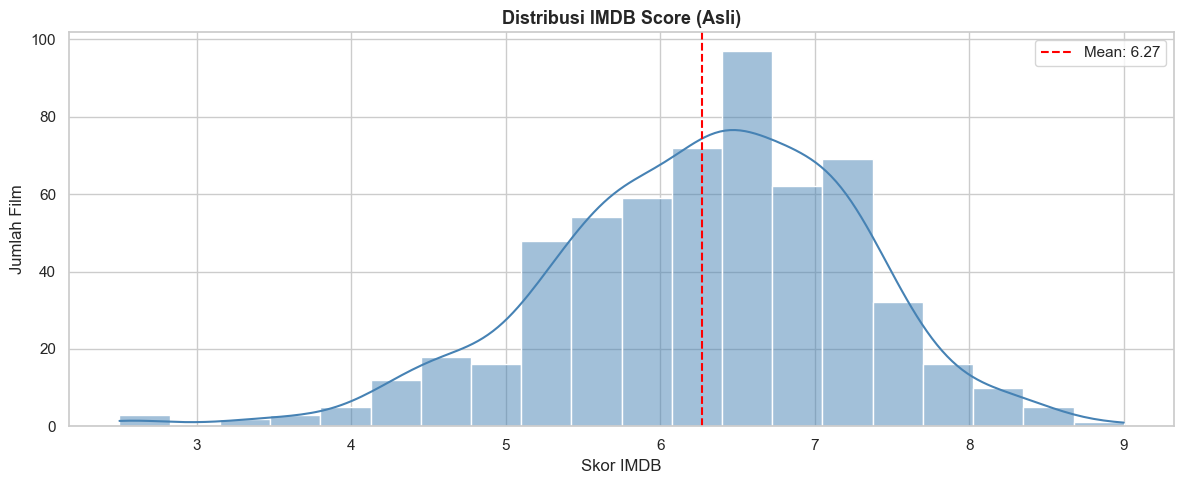

In [17]:
plt.figure(figsize=(12, 5))

sns.histplot(df['IMDB Score'], bins=20, kde=True, color='steelblue')
plt.axvline(df['IMDB Score'].mean(), color='red', linestyle='--', label=f'Mean: {df["IMDB Score"].mean():.2f}')

plt.title('Distribusi IMDB Score (Asli)', fontsize=13, fontweight='bold')
plt.xlabel('Skor IMDB')
plt.ylabel('Jumlah Film')
plt.legend()

plt.tight_layout()
plt.show()

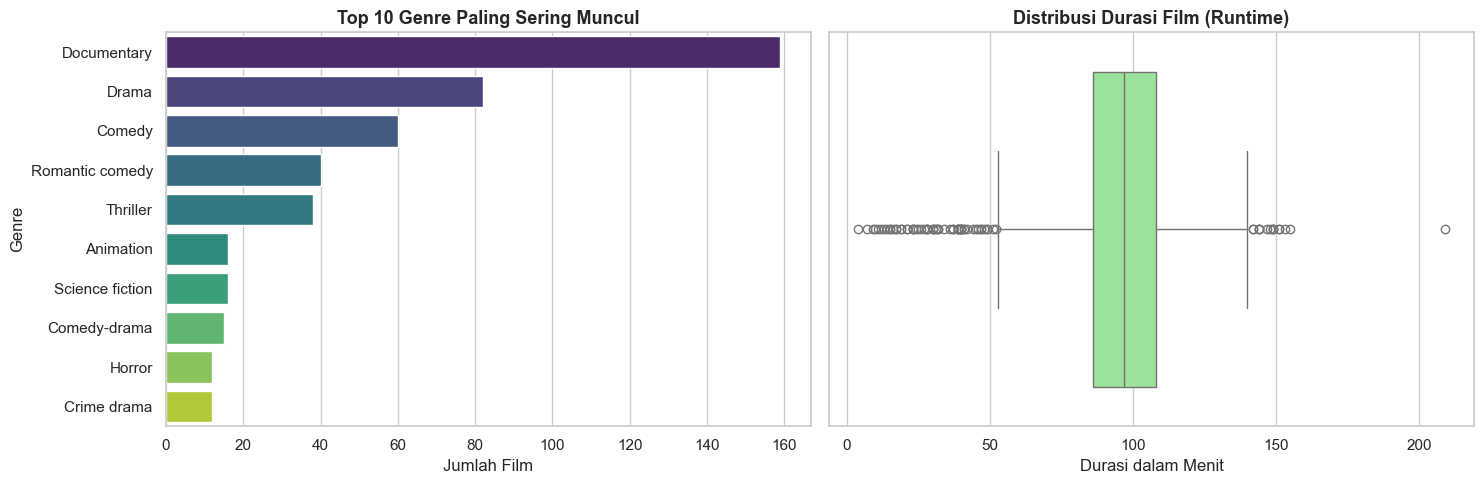

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

all_genres = df['Genre'].dropna().str.split('/').explode().str.strip()
top_genres = all_genres.value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Genre Paling Sering Muncul', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Film')

sns.boxplot(x=df['Runtime'], color='lightgreen', ax=axes[1])
axes[1].set_title('Distribusi Durasi Film (Runtime)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Durasi dalam Menit')

plt.tight_layout()
plt.show()

## Data Preprocessing

In [4]:
if 'User' in df.columns:
    df.drop(columns=['User'], inplace=True)

In [5]:
df.head()

,Title,Genre,Premiere,Runtime,IMDB Score,Language,Year,Real_Actor,Overview
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese,2019,"Kouzou Morishita, Kenji Kamiyama, Yoko Takahas...",What is anime? Through deep-dives with notable...
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish,2020,"Tenoch Huerta MejÃÂ­a, ErÃÂ©ndira Ibarra, Ar...","In search of his sister, a renegade criminal s..."
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian,2019,"Vincenzo Crea, Jessica Cressy, Greta Scarano, ...","Loving girlfriend, family fortune, breakout mo..."
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English,2018,"Dylan Minnette, Piercey Dalton, Sharif Atkins,...",A teenager and his mother find themselves besi...
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi,2020,"Shabana Azmi, Riva Arora, Satyadeep Misra, San...",When a restless spirit curses a Punjab village...


In [6]:
df['Genre']      = df['Genre'].fillna('')
df['Language']   = df['Language'].fillna('')
df['Real_Actor'] = df['Real_Actor'].fillna('')
df['Overview'] = df['Overview'].fillna('')

print('Missing values setelah fill:')
print(df[['Genre', 'Language', 'Real_Actor', 'Overview']].isnull().sum())

Missing values setelah fill:
Genre         0
Language      0
Real_Actor    0
Overview      0
dtype: int64


In [7]:
import unicodedata
import re

def parse_genre_set(g: str) -> set:
    parts = re.split(r'[/,]', g.lower().strip())
    return {p.strip() for p in parts if p.strip()}

def genre_overlap(g1: str, g2: str) -> int:
    return len(parse_genre_set(g1) & parse_genre_set(g2))

def genre_compatible(src_genre: str, cand_genre: str) -> bool:
    src_set  = parse_genre_set(src_genre)
    cand_set = parse_genre_set(cand_genre)

    if len(src_set & cand_set) >= 1:
        return True

    src_words  = set(' '.join(src_set).replace('-', ' ').split())
    cand_words = set(' '.join(cand_set).replace('-', ' ').split())
    return len(src_words & cand_words) >= 1

def clean_tag_field(x):
    if not isinstance(x, str) or not x.strip():
        return ''
    x = unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode('utf-8')
    sep = ',' if ',' in x else '/'
    tokens = [re.sub(r'\s+', '', t.lower().strip()) for t in x.split(sep)]
    return ' '.join(tokens)

def clean_overview(x):
    if not isinstance(x, str) or not x.strip():
        return ''
    x = unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode('utf-8')
    x = re.sub(r'[^a-z0-9\s]', '', x.lower())
    return re.sub(r'\s+', ' ', x).strip()

In [8]:
df['genre_clean']    = df['Genre'].map(clean_tag_field)
df['lang_clean']     = df['Language'].map(clean_tag_field)
df['actor_clean']    = df['Real_Actor'].map(clean_tag_field)
df['overview_clean'] = df['Overview'].fillna('').map(clean_overview)

df['tags'] = (
    df['genre_clean'].apply(lambda x: ' '.join([x] * 5)) + ' ' +
    df['lang_clean'].apply(lambda x: ' '.join([x] * 2)) + ' ' +
    df['actor_clean'] + ' ' +
    df['overview_clean']
).apply(lambda x: ' '.join(x.split()))

print(df[['Title', 'tags']].head(3).to_string())
print(f"\nRata-rata panjang tags: {df['tags'].str.split().apply(len).mean():.0f} kata")

             Title                                                                                                                                                                                                                                                                                                                                                                                                                                                        tags
0  Enter the Anime                                                                                                                                                            documentary documentary documentary documentary documentary english japanese english japanese kouzoumorishita kenjikamiyama yokotakahashi shinjiaramaki what is anime through deepdives with notable masterminds of this electrifying genre this fastpaced documentary seeks to find the answers
1      Dark Forces                                                        

In [24]:
df.head()

,Title,Genre,Premiere,Runtime,IMDB Score,Language,Year,Real_Actor,Overview,genre_clean,lang_clean,actor_clean,overview_clean,tags
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese,2019,"Kouzou Morishita, Kenji Kamiyama, Yoko Takahas...",What is anime? Through deep-dives with notable...,documentary,english japanese,kouzoumorishita kenjikamiyama yokotakahashi sh...,what is anime through deepdives with notable m...,documentary documentary documentary documentar...
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish,2020,"Tenoch Huerta MejÃÂ­a, ErÃÂ©ndira Ibarra, Ar...","In search of his sister, a renegade criminal s...",thriller,spanish,tenochhuertamejaaa eraandiraibarra arianepelli...,in search of his sister a renegade criminal se...,thriller thriller thriller thriller thriller s...
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian,2019,"Vincenzo Crea, Jessica Cressy, Greta Scarano, ...","Loving girlfriend, family fortune, breakout mo...",sciencefiction drama,italian,vincenzocrea jessicacressy gretascarano mayasansa,loving girlfriend family fortune breakout movi...,sciencefiction drama sciencefiction drama scie...
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English,2018,"Dylan Minnette, Piercey Dalton, Sharif Atkins,...",A teenager and his mother find themselves besi...,horrorthriller,english,dylanminnette pierceydalton sharifatkins patri...,a teenager and his mother find themselves besi...,horrorthriller horrorthriller horrorthriller h...
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi,2020,"Shabana Azmi, Riva Arora, Satyadeep Misra, San...",When a restless spirit curses a Punjab village...,mystery,hindi,shabanaazmi rivaarora satyadeepmisra sanjeedas...,when a restless spirit curses a punjab village...,mystery mystery mystery mystery mystery hindi ...


## Feature Engineering

In [9]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(df['tags'])

scaler = MinMaxScaler()
num_features = scaler.fit_transform(
    df[['IMDB Score', 'Runtime']].fillna(df[['IMDB Score', 'Runtime']].median())
)
num_sparse   = sp.csr_matrix(num_features * 0.15)
combined_matrix = sp.hstack([tfidf_matrix, num_sparse])

cosine_sim = cosine_similarity(combined_matrix, combined_matrix)
indices    = pd.Series(df.index, index=df['Title']).groupby(level=0).first()

## 6. Model Training

### Model 1 TF-IDF Content-Based Filtering

In [10]:
def recommend_popular(top_n: int = 10) -> pd.DataFrame:
    return (
        df[['Title', 'Genre', 'IMDB Score', 'Runtime', 'Language']]
        .sort_values('IMDB Score', ascending=False)
        .drop_duplicates(subset='Title')
        .head(top_n)
        .reset_index(drop=True)
    )

def get_cbf_recommendations(
    title: str,
    top_n: int = 10,
    min_similarity: float = 0.05,
    relative_cutoff: float = 0.25,
    genre_filter: bool = True,
    verbose: bool = False
) -> pd.DataFrame:
    if title not in indices:
        print(f"[!] '{title}' tidak ditemukan.")
        return pd.DataFrame()

    idx       = indices[title]
    src_genre = df.loc[idx, 'Genre']
    sims      = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)
    sims      = [(i, s) for i, s in sims if i != idx and s >= min_similarity]

    if not sims:
        return recommend_popular(top_n)

    top_score = sims[0][1]
    sims = [(i, s) for i, s in sims if s >= top_score * relative_cutoff]

    if genre_filter:
        sims = [(i, s) for i, s in sims
                if genre_compatible(src_genre, df.loc[i, 'Genre'])]

    n_organic = len(sims)
    if verbose and n_organic < top_n:
        print(f"[i] '{title}': {n_organic} hasil organik dari {top_n} diminta.")

    if not sims:
        return recommend_popular(top_n)

    top_idx    = [i for i, _ in sims[:top_n]]
    top_scores = [round(s, 4) for _, s in sims[:top_n]]
    result = df[['Title', 'Genre', 'IMDB Score', 'Runtime', 'Language']].iloc[top_idx].copy()
    result['similarity_score'] = top_scores
    return result.reset_index(drop=True)

sample_title = df['Title'].iloc[0]
get_cbf_recommendations(sample_title, top_n=5)

,Title,Genre,IMDB Score,Runtime,Language,similarity_score
0,Little Miss Sumo,Documentary,6.7,19,Japanese,0.4042
1,Voyuer,Documentary,6.2,95,English,0.2941
2,The Legend of Cocaine Island,Documentary,6.3,87,English,0.2939
3,Circus of Books,Documentary,7.1,92,English,0.2935
4,My Beautiful Broken Brain,Documentary,7.1,91,English,0.2935


## Evaluasi Model

# CBF

In [28]:
def build_genre_ground_truth(df: pd.DataFrame, min_shared_genres: int = 1) -> dict:
    ground_truth = {}
    for i, row in df.iterrows():
        src = parse_genre_set(row['Genre'])
        relevant = []
        for j, row2 in df.iterrows():
            if i == j:
                continue
            if len(src & parse_genre_set(row2['Genre'])) >= min_shared_genres:
                relevant.append(row2['Title'])
        ground_truth[row['Title']] = set(relevant)
    return ground_truth

def evaluate_cbf(
    ground_truth: dict,
    k_values: list = [5, 10, 20],
    sample_n: int = 50,
    random_state: int = 42
) -> pd.DataFrame:
    np.random.seed(random_state)
    sample_titles = (
        df['Title'].drop_duplicates()
        .sample(min(sample_n, len(df)), random_state=random_state)
        .tolist()
    )
    results = []
    for k in k_values:
        precisions, recalls, coverages = [], [], []
        for title in sample_titles:
            if title not in ground_truth or title not in indices:
                continue
            recs = get_cbf_recommendations(title, top_n=k, verbose=False)
            if recs.empty:
                continue
            recommended_set = set(recs['Title'].tolist())
            relevant_set    = ground_truth[title]
            if not relevant_set:
                continue
            tp = len(recommended_set & relevant_set)
            precisions.append(tp / k)
            recalls.append(tp / len(relevant_set))
            coverages.append(len(recommended_set) / k)

        p = np.mean(precisions)
        r = np.mean(recalls)
        results.append({
            'k'           : k,
            'precision@k' : round(p, 4),
            'recall@k'    : round(r, 4),
            'f1@k'        : round(2 * p * r / (p + r + 1e-9), 4),
            'coverage'    : round(np.mean(coverages), 4),
            'n_evaluated' : len(precisions)
        })

    print(pd.DataFrame(results).to_string(index=False))
    return pd.DataFrame(results)

# Jalankan
print("ground truth...")
gt = build_genre_ground_truth(df, min_shared_genres=1)

print("evaluasi...")
eval_df = evaluate_cbf(gt, k_values=[5, 10, 20], sample_n=100)

ground truth...
evaluasi...
 k  precision@k  recall@k   f1@k  coverage  n_evaluated
 5       0.9426    0.2842 0.4367    0.9660           94
10       0.8670    0.3745 0.5231    0.9032           94
20       0.7809    0.4832 0.5970    0.8229           94


## Simpan Model

In [ ]:
os.makedirs('model', exist_ok=True)


# TF-IDF vectorizer & cosine sim matrix
joblib.dump(tfidf,      'model/tfidf_vectorizer.pkl')
joblib.dump(cosine_sim, 'model/cosine_sim_matrix.pkl')

# Dataset + features
df.to_csv('model/df_processed.csv', index=False)

## Test Sistem Rekomendasi


In [11]:
genre = df.loc[df['Title'] == 'The Open House'].values[0]
print(f"Genre Searching : {genre}")

Genre Searching : ['The Open House' 'Horror thriller' 'January 19, 2018' 94 3.2 'English'
 2018 'Dylan Minnette, Piercey Dalton, Sharif Atkins, Patricia Bethune'
 'A teenager and his mother find themselves besieged by threatening forces when they move into a new house.'
 'horrorthriller' 'english'
 'dylanminnette pierceydalton sharifatkins patriciabethune'
 'a teenager and his mother find themselves besieged by threatening forces when they move into a new house'
 'horrorthriller horrorthriller horrorthriller horrorthriller horrorthriller english english dylanminnette pierceydalton sharifatkins patriciabethune a teenager and his mother find themselves besieged by threatening forces when they move into a new house']


In [14]:
for title in ['David Attenborough: A Life on Our Planet', 'Taylor Swift: Reputation Stadium Tour', 'The App']:
    print(f"\nTop 5 rekomendasi untuk '{title}':")
    result = get_cbf_recommendations(title, top_n=5, verbose=True)
    if not result.empty:
        print(result[['Title', 'Genre', 'IMDB Score', 'similarity_score']].to_string(index=False))
    print("=" * 65)


Top 5 rekomendasi untuk 'David Attenborough: A Life on Our Planet':
                                       Title       Genre  IMDB Score  similarity_score
Have a Good Trip: Adventures in Psychedelics Documentary         6.8            0.2619
         Guillermo Vilas: Settling the Score Documentary         7.1            0.2481
                                    End Game Documentary         7.1            0.2195
               They'll Love Me When I'm Dead Documentary         7.4            0.1995
                                 City of Joy Documentary         7.5            0.1938

Top 5 rekomendasi untuk 'Taylor Swift: Reputation Stadium Tour':
                                      Title        Genre  IMDB Score  similarity_score
       Ariana Grande: Excuse Me, I Love You Concert Film         6.4            0.5646
Barbra: The Music, The Mem'ries, The Magic! Concert Film         7.5            0.4863
              Shawn Mendes: Live in Concert Concert Film         7.4            0.